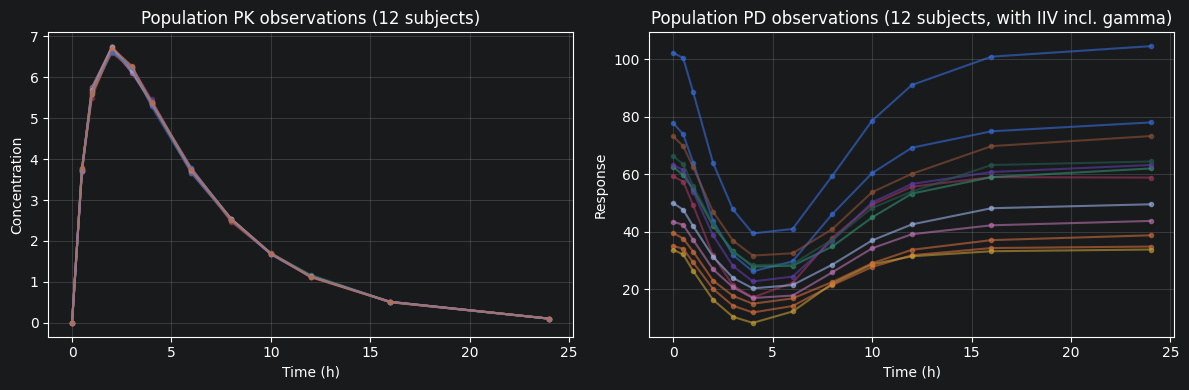

Population data ready (IIV version, gamma included).
pop_data shape = (144, 4)  (rows = 12 * 12)
X shape = torch.Size([144, 1]), Y shape = torch.Size([144, 1]), C_known shape = torch.Size([144, 1]), ID shape = torch.Size([144, 1])

Typical PD params (TV): {'Kin': 25.0, 'Kout': 0.5, 'Imax': 1.0, 'EC50': 4.0, 'gamma': 3.0}
Omega settings: {'V': 0.0, 'ka': 0.0, 'ke': 0.0, 'Kin': 0.25, 'Kout': 0.2, 'Imax': 0.0, 'EC50': 0.0, 'gamma': 0.2}

First 3 sampled individual PD params:
  ID 0: Kin=36.585, Kout=0.477, Imax=1.000, EC50=4.000, gamma=3.498
  ID 1: Kin=18.424, Kout=0.521, Imax=1.000, EC50=4.000, gamma=3.120
  ID 2: Kin=32.129, Kout=0.538, Imax=1.000, EC50=4.000, gamma=4.081

Empirical IIV (log-scale SD) from simulated subjects:
  Kin: 0.272
  Kout: 0.141
  Imax: 0.000
  EC50: 0.000
  gamma: 0.220


In [1]:
# ============================
# Cell 1 (IIV version, gamma included): 导入包 + 生成群体 PK/PD 数据（12个体，含IIV）
# ============================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d
import pandas as pd

# 可复现
np.random.seed(42)
torch.manual_seed(42)

# ----------------------------
# 0) 全局设定
# ----------------------------
n_subjects = 12
t_dense = np.linspace(0, 24, 241)  # 用于数值解真值
t_obs = np.array([0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

# PK 典型值（可视作已知机制）
tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)

# PD 典型值（希望后续识别）
tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)

# IIV（对数正态）标准差，exp(eta), eta~N(0, omega^2)
# 这次把 gamma 也放开
omega = dict(
    V=0.00, ka=0.00, ke=0.00,
    Kin=0.25, Kout=0.20, Imax=0.00, EC50=0.00, gamma=0.20
)

# 残差噪声水平
pd_noise_cv = 0.01
pk_noise_cv = 0.01

# ----------------------------
# 1) 个体参数采样函数
# ----------------------------
def sample_individual_params(tv_pk, tv_pd, omega):
    p = {}
    # PK
    p["D"] = tv_pk["D"]   # 剂量固定
    p["F"] = tv_pk["F"]
    p["V"]  = tv_pk["V"]  * np.exp(np.random.normal(0, omega["V"]))
    p["ka"] = tv_pk["ka"] * np.exp(np.random.normal(0, omega["ka"]))
    p["ke"] = tv_pk["ke"] * np.exp(np.random.normal(0, omega["ke"]))

    # 避免 ka≈ke 数值不稳定
    if abs(p["ka"] - p["ke"]) < 1e-3:
        p["ka"] = p["ke"] + 1e-3

    # PD
    p["Kin"]  = tv_pd["Kin"]  * np.exp(np.random.normal(0, omega["Kin"]))
    p["Kout"] = tv_pd["Kout"] * np.exp(np.random.normal(0, omega["Kout"]))
    p["Imax"] = tv_pd["Imax"] * np.exp(np.random.normal(0, omega["Imax"]))
    p["EC50"] = tv_pd["EC50"] * np.exp(np.random.normal(0, omega["EC50"]))
    p["gamma"] = tv_pd["gamma"] * np.exp(np.random.normal(0, omega["gamma"]))  # <-- gamma加IIV

    # 约束到合理范围
    p["Imax"] = np.clip(p["Imax"], 0.05, 1.5)
    p["EC50"] = max(p["EC50"], 1e-3)
    p["Kout"] = max(p["Kout"], 1e-4)
    p["Kin"]  = max(p["Kin"], 1e-4)
    p["gamma"] = np.clip(p["gamma"], 0.3, 8.0)
    return p

# ----------------------------
# 2) 用个体参数生成 C(t), R(t)
# ----------------------------
all_rows = []          # 每行: [ID, t, C_obs, R_obs]
subject_params = []    # 保存真实个体参数，后面评估用

for sid in range(n_subjects):
    p = sample_individual_params(tv_pk, tv_pd, omega)
    subject_params.append(p)

    # PK: Bateman
    pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
    C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
    C_dense = np.clip(C_dense, 0.0, None)
    C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

    # PD ODE
    def pd_ode(R, t):
        C_t = max(float(C_func(t)), 1e-8)
        hill = (C_t**p["gamma"]) / (p["EC50"]**p["gamma"] + C_t**p["gamma"])
        return p["Kin"] - (p["Kin"] * p["Imax"]) * hill - p["Kout"] * R

    R0 = p["Kin"] / p["Kout"]  # 个体基线
    R_dense = odeint(lambda r, tt: pd_ode(r, tt), R0, t_dense).flatten()

    # 观测点
    C_obs_clean = C_func(t_obs)
    R_obs_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)

    # 加噪声（比例噪声）
    C_obs = C_obs_clean * (1.0 + np.random.normal(0, pk_noise_cv, size=t_obs.shape))
    R_obs = R_obs_clean * (1.0 + np.random.normal(0, pd_noise_cv, size=t_obs.shape))

    C_obs = np.clip(C_obs, 0.0, None)
    R_obs = np.clip(R_obs, 1e-8, None)

    for j, tt in enumerate(t_obs):
        all_rows.append([sid, tt, C_obs[j], R_obs[j]])

pop_data = np.array(all_rows, dtype=float)  # [N,4], N=12*12=144

# ----------------------------
# 3) 组装训练变量（保持与你后续流程兼容）
# ----------------------------
X_np = pop_data[:, 1:2]        # time
C_obs_np = pop_data[:, 2:3]    # observed C
Y_np = pop_data[:, 3:4]        # observed R
ID_np = pop_data[:, 0:1].astype(int)

X = torch.tensor(X_np, dtype=torch.float32)
Y = torch.tensor(Y_np, dtype=torch.float32)
C_known = torch.tensor(C_obs_np, dtype=torch.float32)
ID_tensor = torch.tensor(ID_np, dtype=torch.long)

# ----------------------------
# 4) 可视化
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sid in range(n_subjects):
    idx = (ID_np[:, 0] == sid)
    axes[0].plot(X_np[idx, 0], C_obs_np[idx, 0], '.-', alpha=0.6)
    axes[1].plot(X_np[idx, 0], Y_np[idx, 0], '.-', alpha=0.6)

axes[0].set_title(f"Population PK observations ({n_subjects} subjects)")
axes[0].set_xlabel("Time (h)")
axes[0].set_ylabel("Concentration")
axes[0].grid(alpha=0.3)

axes[1].set_title(f"Population PD observations ({n_subjects} subjects, with IIV incl. gamma)")
axes[1].set_xlabel("Time (h)")
axes[1].set_ylabel("Response")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# 5) 基本检查输出
# ----------------------------
print("Population data ready (IIV version, gamma included).")
print(f"pop_data shape = {pop_data.shape}  (rows = {n_subjects} * {len(t_obs)})")
print(f"X shape = {X.shape}, Y shape = {Y.shape}, C_known shape = {C_known.shape}, ID shape = {ID_tensor.shape}")

print("\nTypical PD params (TV):", tv_pd)
print("Omega settings:", omega)

print("\nFirst 3 sampled individual PD params:")
for i in range(min(3, n_subjects)):
    p = subject_params[i]
    print(f"  ID {i}: Kin={p['Kin']:.3f}, Kout={p['Kout']:.3f}, Imax={p['Imax']:.3f}, EC50={p['EC50']:.3f}, gamma={p['gamma']:.3f}")

# ----------------------------
# 6) 真实IIV（经验值）检查：log-scale SD
# ----------------------------
sp = pd.DataFrame(subject_params)
print("\nEmpirical IIV (log-scale SD) from simulated subjects:")
for k in ["Kin", "Kout", "Imax", "EC50", "gamma"]:
    vals = sp[k].values
    if np.all(vals > 0):
        print(f"  {k}: {np.std(np.log(vals), ddof=1):.3f}")

In [2]:
# ============================
# Cell 2 (Mean-trajectory for structure discovery)
# 用群体时点均值做 DeePyMoD 结构发现，弱化 IIV
# Theta = [1, Hill(C), R]
# ============================
import torch
import torch.nn as nn
from torch.autograd import grad
import pandas as pd
import numpy as np

from deepymod import Library
from deepymod.data import Dataset, get_train_test_loader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---- 1) 从 pop_data 聚合到时点均值 ----
df_pop = pd.DataFrame(pop_data, columns=["sid", "time", "C_obs", "R_obs"])
agg = (
    df_pop.groupby("time", as_index=False)
    .agg(C_mean=("C_obs", "mean"),
         R_mean=("R_obs", "mean"),
         C_std=("C_obs", "std"),
         R_std=("R_obs", "std"),
         n=("sid", "count"))
    .sort_values("time")
    .reset_index(drop=True)
)

# ---- 2) 组装 DeePyMoD 输入 ----
Xg = torch.tensor(agg["time"].values.reshape(-1,1), dtype=torch.float32)   # [T,1]
Cg = torch.tensor(agg["C_mean"].values.reshape(-1,1), dtype=torch.float32) # [T,1]
Yg = torch.tensor(agg["R_mean"].values.reshape(-1,1), dtype=torch.float32) # [T,1]

# 仅标准化 X, Y；C 保持物理域
x_mean, x_std = Xg.mean(), Xg.std()
y_mean, y_std = Yg.mean(), Yg.std()

Xn = (Xg - x_mean) / (x_std + 1e-8)
Yn = (Yg - y_mean) / (y_std + 1e-8)

# 输入列：[time_norm, C_raw]
X_input = torch.cat([Xn, Cg], dim=1).float()
Y_input = Yn.float()

print("Grouped input shapes:",
      "X_input", X_input.shape, "Y_input", Y_input.shape)

def load_grouped_data_for_deepymod():
    return X_input, Y_input

dataset = Dataset(
    load_grouped_data_for_deepymod,
    preprocess_kwargs=dict(
        noise_level=0.0,
        normalize_coords=False,
        normalize_data=False
    ),
    device=device
)
# T=12，尽量保留训练样本；可先不切 test
train_loader, test_loader = get_train_test_loader(dataset, train_test_split=1.0)

# ---- 3) 最小PD库 ----
class PDLibraryMinimalMean(Library):
    def __init__(self):
        super().__init__()
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))
        self.raw_gamma = nn.Parameter(torch.tensor(2.5))

    def library(self, input):
        prediction, data = input
        # data: [B,2] = [time_norm, C_raw]
        R = prediction[:, 0:1]

        dR_ddata = grad(
            R, data,
            grad_outputs=torch.ones_like(R),
            create_graph=True,
            retain_graph=True
        )[0]
        dRdt = dR_ddata[:, 0:1]  # only time derivative

        C = data[:, 1:2].clamp_min(1e-8)

        ec50 = torch.nn.functional.softplus(self.raw_ec50)
        gamma = torch.nn.functional.softplus(self.raw_gamma)
        hill = (C**gamma) / (ec50**gamma + C**gamma)

        one = torch.ones_like(R)
        theta = torch.cat([one, hill, R], dim=1)  # [1, Hill(C), R]
        return [dRdt], [theta]

library = PDLibraryMinimalMean().to(device)

# ---- 4) quick debug ----
for xb, yb in train_loader:
    xb = xb.to(device).clone().detach().requires_grad_(True)
    dummy_net = nn.Sequential(nn.Linear(1, 16), nn.Tanh(), nn.Linear(16, 1)).to(device)
    pred = dummy_net(xb[:, 0:1])   # 网络只用时间
    dts, ths = library((pred, xb))
    print("Debug:",
          "xb", xb.shape,
          "pred", pred.shape,
          "dRdt", dts[0].shape,
          "theta", ths[0].shape)
    break

print("Cell 2 (mean-trajectory) ready.")

Device: cuda
Grouped input shapes: X_input torch.Size([12, 2]) Y_input torch.Size([12, 1])
Preprocessing data
Dataset is using device:  cuda
Debug: xb torch.Size([12, 2]) pred torch.Size([12, 1]) dRdt torch.Size([12, 1]) theta torch.Size([12, 3])
Cell 2 (mean-trajectory) ready.


In [3]:
# ============================
# Cell 3: Mean-trajectory 结构发现训练 + Cell 3.5评测（合并版）
# 适配 Cell 2: X=[time_norm, C_raw], Y=R_norm
# ============================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from deepymod import DeepMoD

# ========= 1) 不做稀疏阈值：恒等估计器 =========
class IdentityEstimator(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, thetas, time_derivs):
        # 全保留
        return [torch.ones(theta.shape[1], dtype=torch.bool, device=theta.device) for theta in thetas]

# ========= 2) Ridge 约束 =========
class Ridge(nn.Module):
    def __init__(self, lam=1e-4):
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input):
        time_derivs, thetas = input
        if self.sparsity_masks is None:
            self.sparsity_masks = [
                torch.ones(theta.shape[1], dtype=torch.bool, device=theta.device)
                for theta in thetas
            ]

        coeffs = []
        for theta, dt, mask in zip(thetas, time_derivs, self.sparsity_masks):
            th = theta[:, mask]
            XtX = th.T @ th
            reg = self.lam * torch.eye(XtX.shape[0], device=XtX.device)
            Xty = th.T @ dt
            w = torch.linalg.pinv(XtX + reg) @ Xty  # 稳定
            full = torch.zeros((mask.shape[0], 1), device=theta.device)
            full[mask] = w
            coeffs.append(full)

        self.coeff_vectors = coeffs
        return coeffs

# ========= 3) 网络：只用时间列 =========
class TimeOnlyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x=[time_norm, C_raw]，仅时间进网络
        xt = x[:, 0:1]
        pred = self.net(xt)
        return pred, x  # DeepMoD要求返回(prediction, coordinates)

# ========= 4) 组装模型 =========
network = TimeOnlyNet().to(device)
estimator = IdentityEstimator().to(device)   # 不阈值
constraint = Ridge(lam=1e-4).to(device)

model = DeepMoD(network, library, estimator, constraint).to(device)

optimizer_nn  = torch.optim.Adam(model.func_approx.parameters(), lr=1e-3)
optimizer_lib = torch.optim.Adam(model.library.parameters(), lr=2e-4)

print("Init EC50,gamma:",
      F.softplus(model.library.raw_ec50).item(),
      F.softplus(model.library.raw_gamma).item())

# ========= 5) 训练 =========
n_epochs = 3000
lambda_reg = 0.2       # ODE残差项权重
lambda_gamma = 1e-4    # 轻微正则，防gamma塌陷

history = {"loss": [], "mse": [], "reg": [], "ec50": [], "gamma": []}

for ep in range(n_epochs):
    for xb, yb in train_loader:
        xb = xb.to(device).clone().detach().requires_grad_(True)
        yb = yb.to(device)

        # 前向
        pred, dts, ths = model(xb)
        mse = torch.mean((pred - yb) ** 2)

        coeffs = model.constraint_coeffs(sparse=True, scaled=False)
        reg = torch.mean(torch.stack([
            torch.mean((dt - th @ cf) ** 2)
            for dt, th, cf in zip(dts, ths, coeffs)
        ]))

        gamma_now = F.softplus(model.library.raw_gamma)
        loss = mse + lambda_reg * reg + lambda_gamma * gamma_now

        optimizer_nn.zero_grad()
        optimizer_lib.zero_grad()
        loss.backward()
        optimizer_nn.step()
        optimizer_lib.step()

    # 记录
    if ep % 100 == 0 or ep == n_epochs - 1:
        ec50_now = F.softplus(model.library.raw_ec50).item()
        gamma_now = F.softplus(model.library.raw_gamma).item()
        history["loss"].append(loss.item())
        history["mse"].append(mse.item())
        history["reg"].append(reg.item())
        history["ec50"].append(ec50_now)
        history["gamma"].append(gamma_now)

        print(f"[ep {ep:4d}] loss={loss.item():.4e} | mse={mse.item():.4e} | "
              f"reg={reg.item():.4e} | EC50={ec50_now:.4f} | gamma={gamma_now:.4f}")

print("Training done.")

# ============================
# Cell 3.5: 结构评测（合并执行）
# ============================
print("\n=== Structure Audit (Cell 3.5) ===")
model.eval()

# 取一个batch计算theta维度
for xb, yb in train_loader:
    xb = xb.to(device).clone().detach().requires_grad_(True)
    pred, dts, ths = model(xb)
    break

theta_dim = ths[0].shape[1]
term_names = np.array(["1", "Hill(C)", "R"][:theta_dim])

mask = model.constraint.sparsity_masks[0].detach().cpu().numpy().astype(bool)
coeff_sparse = model.constraint_coeffs(sparse=True, scaled=False)[0].detach().cpu().numpy().reshape(-1)

print("theta_dim:", theta_dim)
print("term_names:", term_names.tolist())
print("mask:", mask, f"(active={mask.sum()})")
print("coeff_sparse:", coeff_sparse)

# 还原full coeff
full = np.zeros(theta_dim, dtype=float)
active_idx = np.where(mask)[0]
n_assign = min(len(active_idx), len(coeff_sparse))
full[active_idx[:n_assign]] = coeff_sparse[:n_assign]

print("\nFull coeff mapped to [1, Hill(C), R]:")
for n, c in zip(term_names, full):
    print(f"  {n:8s}: {c:+.6f}")

ec50_now = F.softplus(model.library.raw_ec50).item()
gamma_now = F.softplus(model.library.raw_gamma).item()
print("\nLibrary params:")
print(f"  EC50  = {ec50_now:.6f}")
print(f"  gamma = {gamma_now:.6f}")

# 结构判定（最小标准：Hill和R都在）
ok_hill = ("Hill(C)" in term_names[mask]) if mask.sum() > 0 else False
ok_R = ("R" in term_names[mask]) if mask.sum() > 0 else False
print("\nPass check:")
print("  Hill(C) active?", ok_hill)
print("  R active?      ", ok_R)
if ok_hill and ok_R:
    print("  ==> 结构识别通过（可进入后续参数阶段）")
else:
    print("  ==> 结构识别未通过（先继续调结构发现，再谈NLME）")

Init EC50,gamma: 4.0181498527526855 2.578889846801758
[ep    0] loss=9.3905e-01 | mse=9.3875e-01 | reg=2.1801e-04 | EC50=4.0183 | gamma=2.5787
[ep  100] loss=2.7437e-01 | mse=1.4697e-01 | reg=6.3569e-01 | EC50=4.0177 | gamma=2.6009
[ep  200] loss=7.8930e-02 | mse=3.4339e-02 | reg=2.2164e-01 | EC50=4.0553 | gamma=2.6319
[ep  300] loss=6.2157e-03 | mse=2.3511e-03 | reg=1.7997e-02 | EC50=4.0780 | gamma=2.6532
[ep  400] loss=9.2130e-04 | mse=5.8082e-04 | reg=3.7337e-04 | EC50=4.0828 | gamma=2.6581
[ep  500] loss=8.9994e-04 | mse=5.7101e-04 | reg=3.1445e-04 | EC50=4.0849 | gamma=2.6604
[ep  600] loss=8.8088e-04 | mse=5.5683e-04 | reg=2.8879e-04 | EC50=4.0872 | gamma=2.6630
[ep  700] loss=8.6254e-04 | mse=5.4194e-04 | reg=2.7007e-04 | EC50=4.0897 | gamma=2.6658
[ep  800] loss=8.4669e-04 | mse=5.3494e-04 | reg=2.2433e-04 | EC50=4.0924 | gamma=2.6689
[ep  900] loss=8.2602e-04 | mse=5.1063e-04 | reg=2.4088e-04 | EC50=4.0954 | gamma=2.6722
[ep 1000] loss=8.0798e-04 | mse=4.9075e-04 | reg=2.4833e

In [4]:
# ============================
# Cell 4: NLME扩展版（Kin/Kout/gamma 均带随机效应）
# - 固定: EC50 = Cell3估计值, Imax = 1
# - 个体参数: Kin_i, Kout_i, gamma_i（log-scale优化）
# - 输出: pop与omega（含gamma）
# ============================
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matlab
import matlab.engine
import torch.nn.functional as F

# ---------- 0) 准备数据 ----------
df = pd.DataFrame({
    "sid": pop_data[:, 0].astype(int),
    "time": pop_data[:, 1].astype(float),
    "C_obs": pop_data[:, 2].astype(float),
    "R_obs": pop_data[:, 3].astype(float),
})

# 从结构阶段取值：EC50固定，gamma仅作初值（后面个体化）
ec50_fix = float(F.softplus(model.library.raw_ec50).item())
gamma_init = float(F.softplus(model.library.raw_gamma).item())
imax_fix = 1.0

print("Use from structure discovery:")
print(f"  EC50_fix   = {ec50_fix:.6f}")
print(f"  gamma_init = {gamma_init:.6f}")
print(f"  Imax_fix   = {imax_fix:.6f}")

# ---------- 1) 写 MATLAB 脚本 ----------
m_code = r"""
function out = run_iiv_stage_gamma_re(sid, time, conc, resp, Kin0, Kout0, gamma0, EC50_fix, Imax_fix)
sid  = sid(:);
time = time(:);
conc = conc(:);
resp = resp(:);

uids = unique(sid);
nSub = numel(uids);

Kin_i   = zeros(nSub,1);
Kout_i  = zeros(nSub,1);
gamma_i = zeros(nSub,1);
fvals   = zeros(nSub,1);
exitfs  = zeros(nSub,1);

opts = optimset('Display','off','MaxIter',800,'TolX',1e-8,'TolFun',1e-8);

for k = 1:nSub
    id = uids(k);
    idx = find(sid == id);

    tk = time(idx);
    ck = conc(idx);
    yk = resp(idx);

    p0 = log([max(Kin0,1e-8), max(Kout0,1e-8), max(gamma0,1e-6)]);

    obj = @(p) subj_sse3(p, tk, ck, yk, EC50_fix, Imax_fix);
    [ph, fv, ex] = fminsearch(obj, p0, opts);

    th = exp(ph);
    Kin_i(k)   = max(th(1),1e-8);
    Kout_i(k)  = max(th(2),1e-8);
    gamma_i(k) = max(th(3),1e-6);

    fvals(k) = fv;
    exitfs(k)= ex;
end

Kin_pop   = exp(mean(log(Kin_i)));
Kout_pop  = exp(mean(log(Kout_i)));
gamma_pop = exp(mean(log(gamma_i)));

omega_Kin   = std(log(Kin_i), 1);
omega_Kout  = std(log(Kout_i), 1);
omega_gamma = std(log(gamma_i), 1);

yhat_all = nan(size(resp));
for k = 1:nSub
    id = uids(k);
    idx = find(sid == id);
    tk = time(idx);
    ck = conc(idx);
    yhat_all(idx) = subj_pred3(tk, ck, Kin_i(k), Kout_i(k), gamma_i(k), EC50_fix, Imax_fix);
end
rmse = sqrt(mean((resp - yhat_all).^2));

out = struct();
out.ok = true;
out.nObs = numel(resp);
out.nSub = nSub;

out.Kin_pop = Kin_pop;
out.Kout_pop = Kout_pop;
out.gamma_pop = gamma_pop;

out.omega_Kin = omega_Kin;
out.omega_Kout = omega_Kout;
out.omega_gamma = omega_gamma;

out.EC50_fix = EC50_fix;
out.Imax_fix = Imax_fix;

out.Kin_i = Kin_i;
out.Kout_i = Kout_i;
out.gamma_i = gamma_i;

out.fvals = fvals;
out.exitflags = exitfs;
out.rmse = rmse;
end

function val = subj_sse3(p, tk, ck, yk, EC50, Imax)
th = exp(p);
Kin   = max(th(1),1e-8);
Kout  = max(th(2),1e-8);
gamma = max(th(3),1e-6);

yp = subj_pred3(tk, ck, Kin, Kout, gamma, EC50, Imax);
res = yk - yp;
val = sum(res.^2);
end

function yp = subj_pred3(tk, ck, Kin, Kout, gamma, EC50, Imax)
[tk_s, ord] = sort(tk);
ck_s = ck(ord);
cfun = @(tt) interp1(tk_s, ck_s, tt, 'linear', 'extrap');

rhs = @(tt, R) Kin ...
    - (Kin * Imax) * ((max(cfun(tt),1e-10)^gamma) / (EC50^gamma + max(cfun(tt),1e-10)^gamma)) ...
    - Kout * R;

R0 = Kin / Kout;
[~, Rsol] = ode45(rhs, tk_s, R0);

ys = Rsol(:);
yp = zeros(size(tk));
yp(ord) = ys;
end
"""
Path("run_iiv_stage_gamma_re.m").write_text(m_code, encoding="utf-8")
print("Saved:", os.path.abspath("run_iiv_stage_gamma_re.m"))

# ---------- 2) 启动 MATLAB ----------
eng = matlab.engine.start_matlab()

eng.addpath(os.getcwd(), nargout=0)
eng.eval("clear run_iiv_stage_gamma_re", nargout=0)

# ---------- 3) 调用 ----------
sid_m  = matlab.double((df["sid"].values.astype(float) + 1).reshape(-1,1).tolist())  # MATLAB 1-based
time_m = matlab.double(df["time"].values.astype(float).reshape(-1,1).tolist())
conc_m = matlab.double(df["C_obs"].values.astype(float).reshape(-1,1).tolist())
resp_m = matlab.double(df["R_obs"].values.astype(float).reshape(-1,1).tolist())

out_ext = eng.run_iiv_stage_gamma_re(
    sid_m, time_m, conc_m, resp_m,
    float(tv_pd["Kin"]), float(tv_pd["Kout"]), float(gamma_init),
    float(ec50_fix), float(imax_fix),
    nargout=1
)

# ---------- 4) 结果 ----------
Kin_pop_hat = float(out_ext["Kin_pop"])
Kout_pop_hat = float(out_ext["Kout_pop"])
gamma_pop_hat = float(out_ext["gamma_pop"])

omega_Kin_hat = float(out_ext["omega_Kin"])
omega_Kout_hat = float(out_ext["omega_Kout"])
omega_gamma_hat = float(out_ext["omega_gamma"])
rmse_hat = float(out_ext["rmse"])

print("\n=== Extended IIV recovery (Kin/Kout/gamma random effects) ===")
print(f"Kin_pop   hat={Kin_pop_hat:.6f} | true={tv_pd['Kin']:.6f} | err={(Kin_pop_hat-tv_pd['Kin'])/tv_pd['Kin']*100:+.2f}%")
print(f"Kout_pop  hat={Kout_pop_hat:.6f} | true={tv_pd['Kout']:.6f} | err={(Kout_pop_hat-tv_pd['Kout'])/tv_pd['Kout']*100:+.2f}%")
print(f"gamma_pop hat={gamma_pop_hat:.6f} | true={tv_pd['gamma']:.6f} | err={(gamma_pop_hat-tv_pd['gamma'])/tv_pd['gamma']*100:+.2f}%")

print(f"\nomega_Kin   hat={omega_Kin_hat:.6f} | target={omega['Kin']:.6f}")
print(f"omega_Kout  hat={omega_Kout_hat:.6f} | target={omega['Kout']:.6f}")
print(f"omega_gamma hat={omega_gamma_hat:.6f} | target={omega['gamma']:.6f}")

print(f"\nRMSE={rmse_hat:.6f}")

# 与模拟样本经验IIV对照
sp = pd.DataFrame(subject_params)
emp_omega_kin = float(np.std(np.log(sp['Kin'].values), ddof=1))
emp_omega_kout = float(np.std(np.log(sp['Kout'].values), ddof=1))
emp_omega_gamma = float(np.std(np.log(sp['gamma'].values), ddof=1))

print("\nEmpirical from simulated subjects:")
print(f"emp_omega_Kin   = {emp_omega_kin:.6f}")
print(f"emp_omega_Kout  = {emp_omega_kout:.6f}")
print(f"emp_omega_gamma = {emp_omega_gamma:.6f}")

Use from structure discovery:
  EC50_fix   = 4.187290
  gamma_init = 2.766945
  Imax_fix   = 1.000000
Saved: D:\PycharmProjects\DeePyMoD\DeePyNamics\run_iiv_stage_gamma_re.m

=== Extended IIV recovery (Kin/Kout/gamma random effects) ===
Kin_pop   hat=26.158054 | true=25.000000 | err=+4.63%
Kout_pop  hat=0.475562 | true=0.500000 | err=-4.89%
gamma_pop hat=3.234369 | true=3.000000 | err=+7.81%

omega_Kin   hat=0.288306 | target=0.250000
omega_Kout  hat=0.126579 | target=0.200000
omega_gamma hat=0.253168 | target=0.200000

RMSE=0.877506

Empirical from simulated subjects:
emp_omega_Kin   = 0.271817
emp_omega_Kout  = 0.140702
emp_omega_gamma = 0.220111


Device: cuda

[1/10] seed=1 ...
Preprocessing data
Dataset is using device:  cuda

[2/10] seed=2 ...
Preprocessing data
Dataset is using device:  cuda

[3/10] seed=3 ...
Preprocessing data
Dataset is using device:  cuda

[4/10] seed=4 ...
Preprocessing data
Dataset is using device:  cuda

[5/10] seed=5 ...
Preprocessing data
Dataset is using device:  cuda

[6/10] seed=6 ...
Preprocessing data
Dataset is using device:  cuda

[7/10] seed=7 ...
Preprocessing data
Dataset is using device:  cuda

[8/10] seed=8 ...
Preprocessing data
Dataset is using device:  cuda

[9/10] seed=9 ...
Preprocessing data
Dataset is using device:  cuda

[10/10] seed=10 ...
Preprocessing data
Dataset is using device:  cuda

==================== Summary ====================
N seeds = 10
Structure pass rate = 100.0%

Main stats:


,count,mean,std,min,25%,50%,75%,max
Kin_pop_hat,10.0,25.279166,1.051957,23.960276,24.541183,25.013952,25.704121,27.164351
Kout_pop_hat,10.0,0.525472,0.025683,0.485094,0.504004,0.536359,0.540960,0.559384
gamma_pop_hat,10.0,2.995657,0.200221,2.689227,2.873754,2.995639,3.110832,3.363674
omega_Kin_hat,10.0,0.243861,0.096515,0.116430,0.158061,0.252358,0.312290,0.391242
omega_Kout_hat,10.0,0.213113,0.037609,0.150552,0.190815,0.214324,0.246271,0.260834
omega_gamma_hat,10.0,0.195676,0.042107,0.120145,0.169503,0.199733,0.230415,0.250622
RMSE,10.0,0.515741,0.067736,0.424604,0.474686,0.500976,0.553909,0.622973
Kin_pop_err_pct,10.0,1.116664,4.207829,-4.158896,-1.835267,0.055806,2.816485,8.657405
Kout_pop_err_pct,10.0,5.094348,5.136652,-2.981271,0.800819,7.271877,8.191960,11.876798
gamma_pop_err_pct,10.0,-0.144773,6.674042,-10.359097,-4.208192,-0.145381,3.694396,12.122455



Per-seed key results:


,seed,pass_struct,active_terms,Kin_pop_hat,Kout_pop_hat,gamma_pop_hat,omega_Kin_hat,omega_Kout_hat,omega_gamma_hat,omega_Kin_emp,omega_Kout_emp,omega_gamma_emp,RMSE
0,1,True,"1,Hill(C),R",23.960276,0.539600,3.073126,0.214273,0.169696,0.152916,0.204202,0.189796,0.139593,0.495702
1,2,True,"1,Hill(C),R",24.467274,0.533771,3.363674,0.391242,0.189383,0.240284,0.383427,0.219064,0.199772,0.616517
2,3,True,"1,Hill(C),R",24.314098,0.538948,3.158598,0.350492,0.252051,0.197627,0.362816,0.266235,0.174808,0.622973
3,4,True,"1,Hill(C),R",26.819581,0.543873,2.945479,0.116430,0.228649,0.201839,0.134510,0.240784,0.182586,0.498000
4,5,True,"1,Hill(C),R",27.164351,0.489739,3.041407,0.139323,0.234745,0.170638,0.118578,0.274467,0.192612,0.563640
5,6,True,"1,Hill(C),R",25.770610,0.485094,2.689227,0.122578,0.250113,0.120145,0.140222,0.270793,0.140200,0.439626
6,7,True,"1,Hill(C),R",25.053773,0.496560,2.761940,0.239270,0.199999,0.234048,0.240748,0.228254,0.203758,0.467681
7,8,True,"1,Hill(C),R",24.762912,0.526335,3.123400,0.324804,0.260834,0.219518,0.333726,0.288211,0.201668,0.524715
8,9,True,"1,Hill(C),R",25.504654,0.559384,2.949870,0.274747,0.150552,0.250622,0.273156,0.153146,0.227355,0.424604
9,10,True,"1,Hill(C),R",24.974130,0.541413,2.849846,0.265447,0.195111,0.169124,0.255173,0.226831,0.117862,0.503952


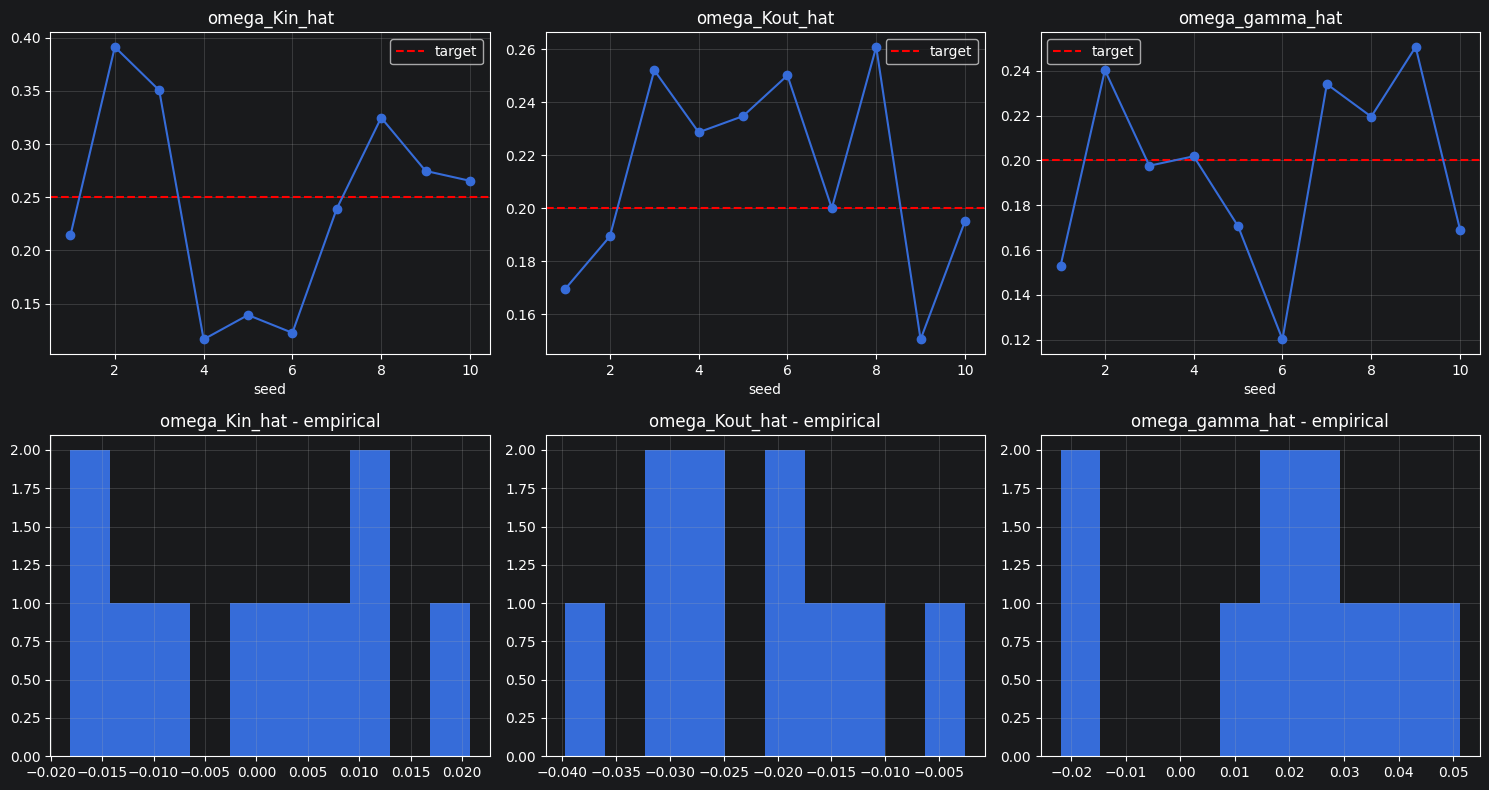


Saved: cell5_multiseed_nlme_gammaRE_summary.csv
Done.


In [5]:
# ============================
# Cell 5: 多seed稳健性验证（NLME阶段含 gamma 随机效应）
# 说明：
# - 与你当前 Cell1/2/3/4 对齐
# - 结构阶段：均值轨迹 + [1, Hill(C), R]
# - NLME阶段：Kin/Kout/gamma 均带随机效应（调用 run_iiv_stage_gamma_re）
# - 输出重点：hat vs target, hat vs empirical（每个seed样本经验IIV）
# ============================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
from scipy.integrate import odeint
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matlab
import matlab.engine

from deepymod import Library, DeepMoD
from deepymod.data import Dataset, get_train_test_loader

# ----------------------------
# 0) 全局设置（与Cell1保持一致）
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

n_subjects = 12
t_dense = np.linspace(0, 24, 241)
t_obs = np.array([0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)
tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)

omega = dict(
    V=0.00, ka=0.00, ke=0.00,
    Kin=0.25, Kout=0.20, Imax=0.00, EC50=0.00, gamma=0.20
)

pd_noise_cv = 0.01
pk_noise_cv = 0.01

# 批量实验参数
seed_list = [1,2,3,4,5,6,7,8,9,10]   # 可扩到20/30
n_epochs = 2000
lambda_reg = 0.2
lambda_gamma = 1e-4

# ----------------------------
# 1) 数据生成（与Cell1一致）
# ----------------------------
def sample_individual_params(tv_pk, tv_pd, omega):
    p = {}
    p["D"] = tv_pk["D"]; p["F"] = tv_pk["F"]
    p["V"]  = tv_pk["V"]  * np.exp(np.random.normal(0, omega["V"]))
    p["ka"] = tv_pk["ka"] * np.exp(np.random.normal(0, omega["ka"]))
    p["ke"] = tv_pk["ke"] * np.exp(np.random.normal(0, omega["ke"]))
    if abs(p["ka"] - p["ke"]) < 1e-3:
        p["ka"] = p["ke"] + 1e-3

    p["Kin"]   = tv_pd["Kin"]   * np.exp(np.random.normal(0, omega["Kin"]))
    p["Kout"]  = tv_pd["Kout"]  * np.exp(np.random.normal(0, omega["Kout"]))
    p["Imax"]  = tv_pd["Imax"]  * np.exp(np.random.normal(0, omega["Imax"]))
    p["EC50"]  = tv_pd["EC50"]  * np.exp(np.random.normal(0, omega["EC50"]))
    p["gamma"] = tv_pd["gamma"] * np.exp(np.random.normal(0, omega["gamma"]))

    p["Imax"] = np.clip(p["Imax"], 0.05, 1.5)
    p["EC50"] = max(p["EC50"], 1e-3)
    p["Kout"] = max(p["Kout"], 1e-4)
    p["Kin"]  = max(p["Kin"], 1e-4)
    p["gamma"] = np.clip(p["gamma"], 0.3, 8.0)
    return p

def generate_population_data(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

    all_rows = []
    subject_params = []

    for sid in range(n_subjects):
        p = sample_individual_params(tv_pk, tv_pd, omega)
        subject_params.append(p)

        pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
        C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
        C_dense = np.clip(C_dense, 0.0, None)
        C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

        def pd_ode(R, t):
            C_t = max(float(C_func(t)), 1e-8)
            hill = (C_t**p["gamma"]) / (p["EC50"]**p["gamma"] + C_t**p["gamma"])
            return p["Kin"] - (p["Kin"] * p["Imax"]) * hill - p["Kout"] * R

        R0 = p["Kin"] / p["Kout"]
        R_dense = odeint(lambda r, tt: pd_ode(r, tt), R0, t_dense).flatten()

        C_obs_clean = C_func(t_obs)
        R_obs_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)

        C_obs = C_obs_clean * (1.0 + np.random.normal(0, pk_noise_cv, size=t_obs.shape))
        R_obs = R_obs_clean * (1.0 + np.random.normal(0, pd_noise_cv, size=t_obs.shape))
        C_obs = np.clip(C_obs, 0.0, None)
        R_obs = np.clip(R_obs, 1e-8, None)

        for j, tt in enumerate(t_obs):
            all_rows.append([sid, tt, C_obs[j], R_obs[j]])

    pop_data = np.array(all_rows, dtype=float)
    return pop_data, subject_params

# ----------------------------
# 2) 结构发现模块（与Cell2/3一致的简化版）
# ----------------------------
class PDLibraryMinimalMean(Library):
    def __init__(self):
        super().__init__()
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))
        self.raw_gamma = nn.Parameter(torch.tensor(2.5))

    def library(self, input):
        prediction, data = input
        R = prediction[:, 0:1]
        dR_ddata = grad(R, data, grad_outputs=torch.ones_like(R), create_graph=True, retain_graph=True)[0]
        dRdt = dR_ddata[:, 0:1]
        C = data[:, 1:2].clamp_min(1e-8)

        ec50 = F.softplus(self.raw_ec50)
        gamma = F.softplus(self.raw_gamma)
        hill = (C**gamma) / (ec50**gamma + C**gamma)

        one = torch.ones_like(R)
        theta = torch.cat([one, hill, R], dim=1)
        return [dRdt], [theta]

class IdentityEstimator(nn.Module):
    def forward(self, thetas, time_derivs):
        return [torch.ones(theta.shape[1], dtype=torch.bool, device=theta.device) for theta in thetas]

class Ridge(nn.Module):
    def __init__(self, lam=1e-4):
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input):
        time_derivs, thetas = input
        if self.sparsity_masks is None:
            self.sparsity_masks = [torch.ones(t.shape[1], dtype=torch.bool, device=t.device) for t in thetas]

        coeffs = []
        for theta, dt, mask in zip(thetas, time_derivs, self.sparsity_masks):
            th = theta[:, mask]
            XtX = th.T @ th
            reg = self.lam * torch.eye(XtX.shape[0], device=XtX.device)
            Xty = th.T @ dt
            w = torch.linalg.pinv(XtX + reg) @ Xty
            full = torch.zeros((mask.shape[0], 1), device=theta.device)
            full[mask] = w
            coeffs.append(full)

        self.coeff_vectors = coeffs
        return coeffs

class TimeOnlyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        xt = x[:, 0:1]
        pred = self.net(xt)
        return pred, x

def run_structure_discovery(pop_data, epochs=2000):
    df_pop = pd.DataFrame(pop_data, columns=["sid", "time", "C_obs", "R_obs"])
    agg = (df_pop.groupby("time", as_index=False)
                 .agg(C_mean=("C_obs", "mean"), R_mean=("R_obs", "mean"))
                 .sort_values("time")
                 .reset_index(drop=True))

    Xg = torch.tensor(agg["time"].values.reshape(-1,1), dtype=torch.float32)
    Cg = torch.tensor(agg["C_mean"].values.reshape(-1,1), dtype=torch.float32)
    Yg = torch.tensor(agg["R_mean"].values.reshape(-1,1), dtype=torch.float32)

    Xn = (Xg - Xg.mean()) / (Xg.std() + 1e-8)
    Yn = (Yg - Yg.mean()) / (Yg.std() + 1e-8)

    X_input = torch.cat([Xn, Cg], dim=1).float()
    Y_input = Yn.float()

    def loader():
        return X_input, Y_input

    dataset = Dataset(loader, preprocess_kwargs=dict(noise_level=0.0, normalize_coords=False, normalize_data=False), device=device)
    train_loader, _ = get_train_test_loader(dataset, train_test_split=1.0)

    network = TimeOnlyNet().to(device)
    library = PDLibraryMinimalMean().to(device)
    estimator = IdentityEstimator().to(device)
    constraint = Ridge(lam=1e-4).to(device)
    model_local = DeepMoD(network, library, estimator, constraint).to(device)

    opt_nn  = torch.optim.Adam(model_local.func_approx.parameters(), lr=1e-3)
    opt_lib = torch.optim.Adam(model_local.library.parameters(), lr=2e-4)

    for _ in range(epochs):
        for xb, yb in train_loader:
            xb = xb.to(device).clone().detach().requires_grad_(True)
            yb = yb.to(device)

            pred, dts, ths = model_local(xb)
            mse = torch.mean((pred - yb)**2)
            coeffs = model_local.constraint_coeffs(sparse=True, scaled=False)
            reg = torch.mean(torch.stack([torch.mean((dt - th @ cf)**2) for dt, th, cf in zip(dts, ths, coeffs)]))
            gamma_now = F.softplus(model_local.library.raw_gamma)

            loss = mse + lambda_reg * reg + lambda_gamma * gamma_now
            opt_nn.zero_grad(); opt_lib.zero_grad()
            loss.backward()
            opt_nn.step(); opt_lib.step()

    mask = model_local.constraint.sparsity_masks[0].detach().cpu().numpy().astype(bool)
    term_names = np.array(["1", "Hill(C)", "R"])
    active_terms = set(term_names[mask].tolist())
    pass_struct = ("Hill(C)" in active_terms) and ("R" in active_terms)

    ec50_hat = float(F.softplus(model_local.library.raw_ec50).item())
    gamma_hat = float(F.softplus(model_local.library.raw_gamma).item())

    return dict(
        pass_struct=pass_struct,
        active_terms=",".join(sorted(list(active_terms))),
        ec50_hat=ec50_hat,
        gamma_hat=gamma_hat
    )

# ----------------------------
# 3) MATLAB函数（若不存在则写入）
# ----------------------------
from pathlib import Path
import os

m_path = Path("run_iiv_stage_gamma_re.m")
if not m_path.exists():
    m_code = r"""
function out = run_iiv_stage_gamma_re(sid, time, conc, resp, Kin0, Kout0, gamma0, EC50_fix, Imax_fix)
sid=sid(:); time=time(:); conc=conc(:); resp=resp(:);
uids = unique(sid); nSub=numel(uids);
Kin_i=zeros(nSub,1); Kout_i=zeros(nSub,1); gamma_i=zeros(nSub,1);
opts=optimset('Display','off','MaxIter',800,'TolX',1e-8,'TolFun',1e-8);
for k=1:nSub
    idx=find(sid==uids(k)); tk=time(idx); ck=conc(idx); yk=resp(idx);
    p0=log([max(Kin0,1e-8), max(Kout0,1e-8), max(gamma0,1e-6)]);
    obj=@(p) subj_sse3(p, tk, ck, yk, EC50_fix, Imax_fix);
    ph=fminsearch(obj,p0,opts); th=exp(ph);
    Kin_i(k)=max(th(1),1e-8); Kout_i(k)=max(th(2),1e-8); gamma_i(k)=max(th(3),1e-6);
end
Kin_pop=exp(mean(log(Kin_i))); Kout_pop=exp(mean(log(Kout_i))); gamma_pop=exp(mean(log(gamma_i)));
omega_Kin=std(log(Kin_i),1); omega_Kout=std(log(Kout_i),1); omega_gamma=std(log(gamma_i),1);
yhat_all=nan(size(resp));
for k=1:nSub
    idx=find(sid==uids(k)); tk=time(idx); ck=conc(idx);
    yhat_all(idx)=subj_pred3(tk, ck, Kin_i(k), Kout_i(k), gamma_i(k), EC50_fix, Imax_fix);
end
rmse=sqrt(mean((resp-yhat_all).^2));
out=struct('Kin_pop',Kin_pop,'Kout_pop',Kout_pop,'gamma_pop',gamma_pop, ...
           'omega_Kin',omega_Kin,'omega_Kout',omega_Kout,'omega_gamma',omega_gamma, ...
           'Kin_i',Kin_i,'Kout_i',Kout_i,'gamma_i',gamma_i,'rmse',rmse,'nSub',nSub,'ok',true);
end
function val = subj_sse3(p, tk, ck, yk, EC50, Imax)
th=exp(p); Kin=max(th(1),1e-8); Kout=max(th(2),1e-8); gamma=max(th(3),1e-6);
yp=subj_pred3(tk,ck,Kin,Kout,gamma,EC50,Imax); val=sum((yk-yp).^2);
end
function yp = subj_pred3(tk, ck, Kin, Kout, gamma, EC50, Imax)
[tk_s,ord]=sort(tk); ck_s=ck(ord); cfun=@(tt) interp1(tk_s,ck_s,tt,'linear','extrap');
rhs=@(tt,R) Kin-(Kin*Imax)*((max(cfun(tt),1e-10)^gamma)/(EC50^gamma+max(cfun(tt),1e-10)^gamma))-Kout*R;
R0=Kin/Kout; [~,Rsol]=ode45(rhs,tk_s,R0); ys=Rsol(:); yp=zeros(size(tk)); yp(ord)=ys;
end
"""
    m_path.write_text(m_code, encoding="utf-8")
    print("Created:", os.path.abspath(str(m_path)))

# ----------------------------
# 4) 启动 MATLAB
# ----------------------------
try:
    eng
except NameError:
    eng = matlab.engine.start_matlab()
eng.addpath(os.getcwd(), nargout=0)
eng.eval("clear run_iiv_stage_gamma_re", nargout=0)

def run_nlme_gamma_re(pop_data, ec50_fix, gamma_init, eng):
    df = pd.DataFrame({
        "sid": pop_data[:,0].astype(int),
        "time": pop_data[:,1].astype(float),
        "C_obs": pop_data[:,2].astype(float),
        "R_obs": pop_data[:,3].astype(float),
    })

    sid_m  = matlab.double((df["sid"].values.astype(float) + 1).reshape(-1,1).tolist())
    time_m = matlab.double(df["time"].values.astype(float).reshape(-1,1).tolist())
    conc_m = matlab.double(df["C_obs"].values.astype(float).reshape(-1,1).tolist())
    resp_m = matlab.double(df["R_obs"].values.astype(float).reshape(-1,1).tolist())

    out = eng.run_iiv_stage_gamma_re(
        sid_m, time_m, conc_m, resp_m,
        float(tv_pd["Kin"]), float(tv_pd["Kout"]), float(gamma_init),
        float(ec50_fix), 1.0,
        nargout=1
    )
    return {
        "Kin_pop_hat": float(out["Kin_pop"]),
        "Kout_pop_hat": float(out["Kout_pop"]),
        "gamma_pop_hat": float(out["gamma_pop"]),
        "omega_Kin_hat": float(out["omega_Kin"]),
        "omega_Kout_hat": float(out["omega_Kout"]),
        "omega_gamma_hat": float(out["omega_gamma"]),
        "RMSE": float(out["rmse"]),
    }

# ----------------------------
# 5) 批量运行
# ----------------------------
records = []
for i, sd in enumerate(seed_list, 1):
    print(f"\n[{i}/{len(seed_list)}] seed={sd} ...")
    pop_data_i, subj_params_i = generate_population_data(sd)

    sres = run_structure_discovery(pop_data_i, epochs=n_epochs)
    nres = run_nlme_gamma_re(pop_data_i, sres["ec50_hat"], sres["gamma_hat"], eng)

    sp = pd.DataFrame(subj_params_i)
    emp_omega_kin = float(np.std(np.log(sp["Kin"].values), ddof=1))
    emp_omega_kout = float(np.std(np.log(sp["Kout"].values), ddof=1))
    emp_omega_gamma = float(np.std(np.log(sp["gamma"].values), ddof=1))

    row = {
        "seed": sd,
        "pass_struct": sres["pass_struct"],
        "active_terms": sres["active_terms"],
        "EC50_hat": sres["ec50_hat"],
        "gamma_init_hat": sres["gamma_hat"],

        "Kin_pop_hat": nres["Kin_pop_hat"],
        "Kout_pop_hat": nres["Kout_pop_hat"],
        "gamma_pop_hat": nres["gamma_pop_hat"],

        "omega_Kin_hat": nres["omega_Kin_hat"],
        "omega_Kout_hat": nres["omega_Kout_hat"],
        "omega_gamma_hat": nres["omega_gamma_hat"],
        "RMSE": nres["RMSE"],

        "Kin_pop_err_pct": (nres["Kin_pop_hat"] - tv_pd["Kin"]) / tv_pd["Kin"] * 100.0,
        "Kout_pop_err_pct": (nres["Kout_pop_hat"] - tv_pd["Kout"]) / tv_pd["Kout"] * 100.0,
        "gamma_pop_err_pct": (nres["gamma_pop_hat"] - tv_pd["gamma"]) / tv_pd["gamma"] * 100.0,

        "omega_Kin_target": omega["Kin"],
        "omega_Kout_target": omega["Kout"],
        "omega_gamma_target": omega["gamma"],

        "omega_Kin_emp": emp_omega_kin,
        "omega_Kout_emp": emp_omega_kout,
        "omega_gamma_emp": emp_omega_gamma,

        "omega_Kin_vs_target": nres["omega_Kin_hat"] - omega["Kin"],
        "omega_Kout_vs_target": nres["omega_Kout_hat"] - omega["Kout"],
        "omega_gamma_vs_target": nres["omega_gamma_hat"] - omega["gamma"],

        "omega_Kin_vs_emp": nres["omega_Kin_hat"] - emp_omega_kin,
        "omega_Kout_vs_emp": nres["omega_Kout_hat"] - emp_omega_kout,
        "omega_gamma_vs_emp": nres["omega_gamma_hat"] - emp_omega_gamma,
    }
    records.append(row)

df_res = pd.DataFrame(records)

# ----------------------------
# 6) 汇总输出（重点看IIV）
# ----------------------------
print("\n==================== Summary ====================")
print(f"N seeds = {len(df_res)}")
print(f"Structure pass rate = {df_res['pass_struct'].mean()*100:.1f}%")

summary_cols = [
    "Kin_pop_hat","Kout_pop_hat","gamma_pop_hat",
    "omega_Kin_hat","omega_Kout_hat","omega_gamma_hat","RMSE",
    "Kin_pop_err_pct","Kout_pop_err_pct","gamma_pop_err_pct",
    "omega_Kin_vs_target","omega_Kout_vs_target","omega_gamma_vs_target",
    "omega_Kin_vs_emp","omega_Kout_vs_emp","omega_gamma_vs_emp"
]
print("\nMain stats:")
display(df_res[summary_cols].describe().T)

print("\nPer-seed key results:")
display(df_res[[
    "seed","pass_struct","active_terms",
    "Kin_pop_hat","Kout_pop_hat","gamma_pop_hat",
    "omega_Kin_hat","omega_Kout_hat","omega_gamma_hat",
    "omega_Kin_emp","omega_Kout_emp","omega_gamma_emp",
    "RMSE"
]].sort_values("seed"))

# ----------------------------
# 7) 可视化
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# omega by seed
axes[0,0].axhline(omega["Kin"], color='r', ls='--', label='target')
axes[0,0].plot(df_res["seed"], df_res["omega_Kin_hat"], 'o-')
axes[0,0].set_title("omega_Kin_hat")
axes[0,0].set_xlabel("seed"); axes[0,0].grid(alpha=0.3); axes[0,0].legend()

axes[0,1].axhline(omega["Kout"], color='r', ls='--', label='target')
axes[0,1].plot(df_res["seed"], df_res["omega_Kout_hat"], 'o-')
axes[0,1].set_title("omega_Kout_hat")
axes[0,1].set_xlabel("seed"); axes[0,1].grid(alpha=0.3); axes[0,1].legend()

axes[0,2].axhline(omega["gamma"], color='r', ls='--', label='target')
axes[0,2].plot(df_res["seed"], df_res["omega_gamma_hat"], 'o-')
axes[0,2].set_title("omega_gamma_hat")
axes[0,2].set_xlabel("seed"); axes[0,2].grid(alpha=0.3); axes[0,2].legend()

# residual style
axes[1,0].hist(df_res["omega_Kin_vs_emp"], bins=10)
axes[1,0].set_title("omega_Kin_hat - empirical")
axes[1,0].grid(alpha=0.3)

axes[1,1].hist(df_res["omega_Kout_vs_emp"], bins=10)
axes[1,1].set_title("omega_Kout_hat - empirical")
axes[1,1].grid(alpha=0.3)

axes[1,2].hist(df_res["omega_gamma_vs_emp"], bins=10)
axes[1,2].set_title("omega_gamma_hat - empirical")
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# 8) 保存
# ----------------------------
out_csv = "cell5_multiseed_nlme_gammaRE_summary.csv"
#df_res.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"\nSaved: {out_csv}")
print("Done.")

Preprocessing data
Dataset is using device:  cuda


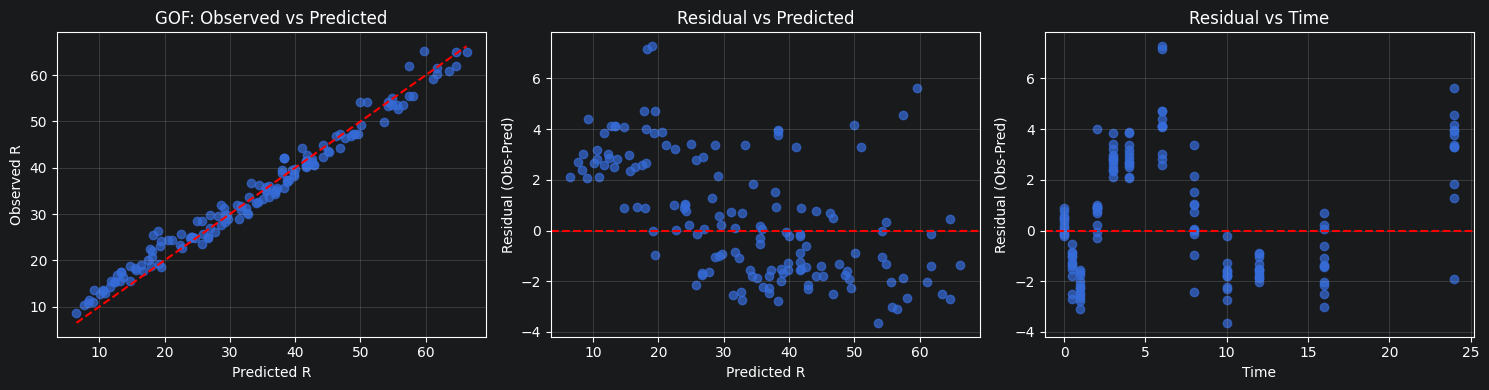

[Representative seed=1] RMSE=0.4957


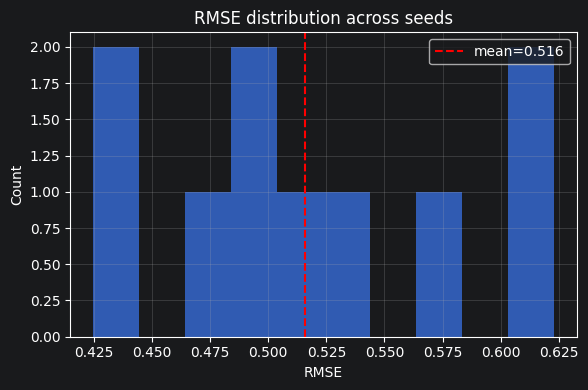

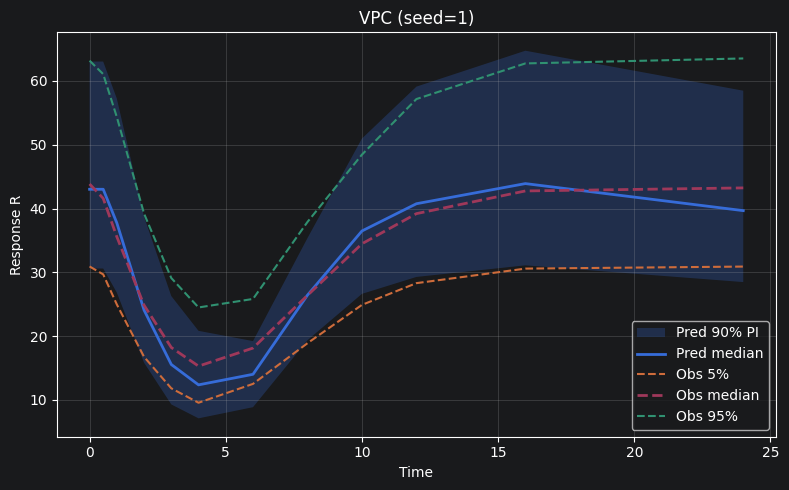

Bootstrap success: 100/100


,param,p2.5,p50,p97.5
0,Kin_pop,21.369776,23.951749,26.898744
1,Kout_pop,0.491632,0.537923,0.587212
2,gamma_pop,2.838396,3.065442,3.375121
3,omega_Kin,0.121998,0.207192,0.270926
4,omega_Kout,0.089054,0.162264,0.223989
5,omega_gamma,0.103208,0.145495,0.189866
6,RMSE,0.386960,0.498269,0.623470


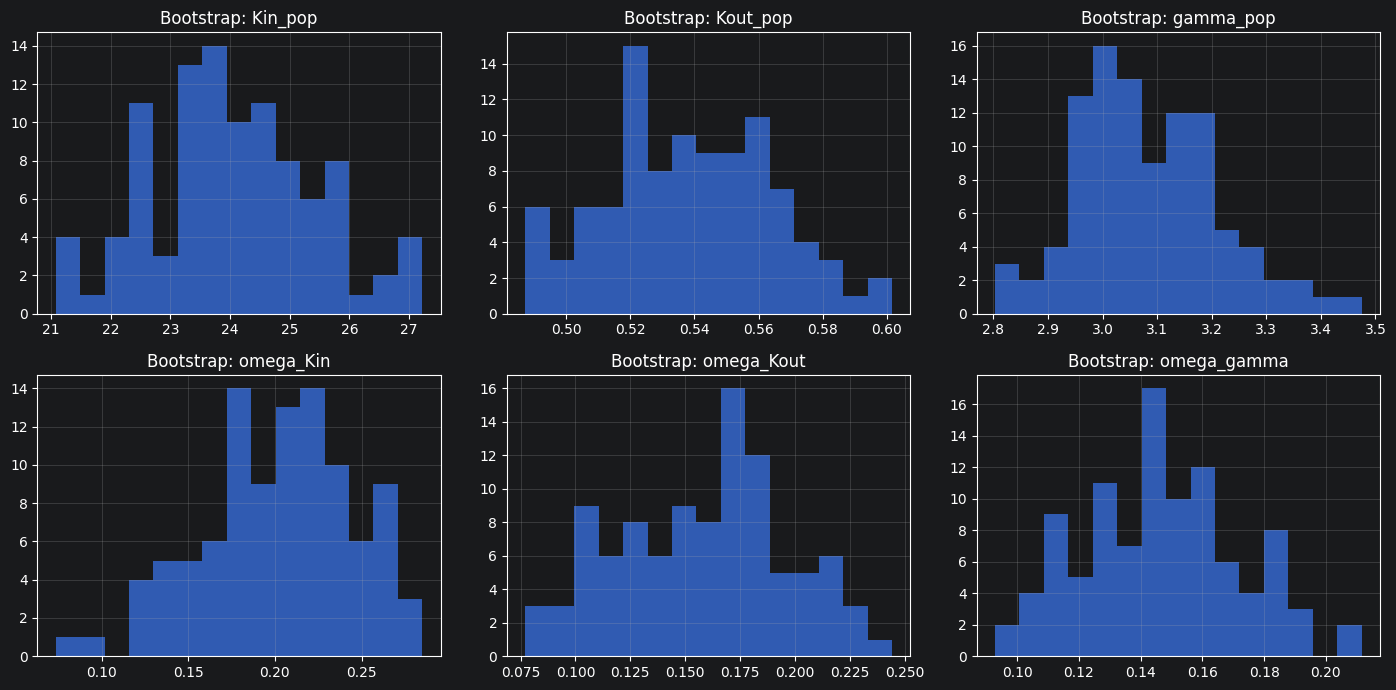

Saved: cell6_bootstrap_samples.csv, cell6_bootstrap_ci95.csv, cell6_vpc_seed_rep.csv


In [6]:
# ============================
# Cell 6: PK/PD-NLME 常用评估图
# GOF / RMSE / VPC / Bootstrap CI
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matlab
import matlab.engine

# ---------- 0) 工具函数 ----------
def matlab_col(v):
    return matlab.double(np.asarray(v, dtype=float).reshape(-1,1).tolist())

def nlme_fit_once(pop_data, ec50_fix, gamma_init, tv_pd, eng):
    """调用 run_iiv_stage_gamma_re 并返回结果dict"""
    df = pd.DataFrame({
        "sid": pop_data[:,0].astype(int),
        "time": pop_data[:,1].astype(float),
        "C_obs": pop_data[:,2].astype(float),
        "R_obs": pop_data[:,3].astype(float),
    })
    out = eng.run_iiv_stage_gamma_re(
        matlab_col(df["sid"].values + 1),  # MATLAB 1-based
        matlab_col(df["time"].values),
        matlab_col(df["C_obs"].values),
        matlab_col(df["R_obs"].values),
        float(tv_pd["Kin"]), float(tv_pd["Kout"]), float(gamma_init),
        float(ec50_fix), 1.0, nargout=1
    )
    return {
        "Kin_pop": float(out["Kin_pop"]),
        "Kout_pop": float(out["Kout_pop"]),
        "gamma_pop": float(out["gamma_pop"]),
        "omega_Kin": float(out["omega_Kin"]),
        "omega_Kout": float(out["omega_Kout"]),
        "omega_gamma": float(out["omega_gamma"]),
        "Kin_i": np.array(out["Kin_i"]).ravel(),
        "Kout_i": np.array(out["Kout_i"]).ravel(),
        "gamma_i": np.array(out["gamma_i"]).ravel(),
        "rmse": float(out["rmse"]),
    }, df

def simulate_subject_pred(time_vec, conc_vec, Kin, Kout, gamma, EC50, Imax=1.0):
    """Python端重建个体R(t)预测（和MATLAB模型一致）"""
    # time按升序
    ord_idx = np.argsort(time_vec)
    t = np.asarray(time_vec)[ord_idx]
    c = np.asarray(conc_vec)[ord_idx]

    # 线性插值C(t)
    def cfun(tt):
        return np.interp(tt, t, c)

    # ODE积分（简单欧拉，观测点很少时够用；想更精确可换odeint）
    R = np.zeros_like(t, dtype=float)
    R[0] = Kin / Kout
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        c_prev = max(cfun(t[i-1]), 1e-10)
        hill = (c_prev**gamma) / (EC50**gamma + c_prev**gamma)
        dR = Kin - (Kin*Imax)*hill - Kout*R[i-1]
        R[i] = R[i-1] + dt*dR

    y = np.zeros_like(R)
    y[ord_idx.argsort()] = R
    return y

# ---------- 1) 选一个“代表seed”做GOF和VPC ----------
seed_rep = 1
pop_data_rep, subj_params_rep = generate_population_data(seed_rep)

# 结构阶段给EC50/gamma初值（可换成你Cell3当前值）
sres_rep = run_structure_discovery(pop_data_rep, epochs=2000)
ec50_fix_rep = sres_rep["ec50_hat"]
gamma_init_rep = sres_rep["gamma_hat"]

fit_rep, df_rep = nlme_fit_once(pop_data_rep, ec50_fix_rep, gamma_init_rep, tv_pd, eng)

# 构建个体预测
uids = sorted(df_rep["sid"].unique().tolist())
pred_all = np.zeros(len(df_rep), dtype=float)

for k, sid in enumerate(uids):
    idx = (df_rep["sid"].values == sid)
    t_k = df_rep.loc[idx, "time"].values
    c_k = df_rep.loc[idx, "C_obs"].values
    pred_k = simulate_subject_pred(
        t_k, c_k,
        fit_rep["Kin_i"][k], fit_rep["Kout_i"][k], fit_rep["gamma_i"][k],
        ec50_fix_rep, 1.0
    )
    pred_all[idx] = pred_k

df_rep["R_pred"] = pred_all
df_rep["RES"] = df_rep["R_obs"] - df_rep["R_pred"]

# ---------- 2) GOF图 ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Obs vs Pred
axes[0].scatter(df_rep["R_pred"], df_rep["R_obs"], alpha=0.7)
mn = min(df_rep["R_pred"].min(), df_rep["R_obs"].min())
mx = max(df_rep["R_pred"].max(), df_rep["R_obs"].max())
axes[0].plot([mn, mx], [mn, mx], 'r--')
axes[0].set_xlabel("Predicted R")
axes[0].set_ylabel("Observed R")
axes[0].set_title("GOF: Observed vs Predicted")
axes[0].grid(alpha=0.3)

# Residual vs Pred
axes[1].scatter(df_rep["R_pred"], df_rep["RES"], alpha=0.7)
axes[1].axhline(0, color='r', ls='--')
axes[1].set_xlabel("Predicted R")
axes[1].set_ylabel("Residual (Obs-Pred)")
axes[1].set_title("Residual vs Predicted")
axes[1].grid(alpha=0.3)

# Residual vs Time
axes[2].scatter(df_rep["time"], df_rep["RES"], alpha=0.7)
axes[2].axhline(0, color='r', ls='--')
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Residual (Obs-Pred)")
axes[2].set_title("Residual vs Time")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"[Representative seed={seed_rep}] RMSE={fit_rep['rmse']:.4f}")

# ---------- 3) RMSE分布（来自Cell5结果df_res） ----------
plt.figure(figsize=(6,4))
plt.hist(df_res["RMSE"], bins=10, alpha=0.8)
plt.axvline(df_res["RMSE"].mean(), color='r', ls='--', label=f"mean={df_res['RMSE'].mean():.3f}")
plt.title("RMSE distribution across seeds")
plt.xlabel("RMSE")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 4) VPC（基于代表seed，按时间分位数） ----------
# 观测分位数
obs_q = df_rep.groupby("time")["R_obs"].quantile([0.05,0.5,0.95]).unstack()
obs_q.columns = ["q05_obs","q50_obs","q95_obs"]

# 预测分位数
pred_q = df_rep.groupby("time")["R_pred"].quantile([0.05,0.5,0.95]).unstack()
pred_q.columns = ["q05_pred","q50_pred","q95_pred"]

vpc = obs_q.join(pred_q, how="inner").reset_index()

plt.figure(figsize=(8,5))
t = vpc["time"].values

# 预测90%区间带
plt.fill_between(t, vpc["q05_pred"], vpc["q95_pred"], alpha=0.25, label="Pred 90% PI")
plt.plot(t, vpc["q50_pred"], '-', lw=2, label="Pred median")

# 观测分位线
plt.plot(t, vpc["q05_obs"], '--', lw=1.5, label="Obs 5%")
plt.plot(t, vpc["q50_obs"], '--', lw=2, label="Obs median")
plt.plot(t, vpc["q95_obs"], '--', lw=1.5, label="Obs 95%")

plt.xlabel("Time")
plt.ylabel("Response R")
plt.title(f"VPC (seed={seed_rep})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 5) Bootstrap（参数不确定性） ----------
# 方法：固定一个代表seed数据，对“受试者重采样”做bootstrap
B = 100   # 可先50调试，再200
rng = np.random.default_rng(2026)

df0 = df_rep.copy()
uids0 = sorted(df0["sid"].unique().tolist())

boot_rows = []
for b in range(B):
    sampled = rng.choice(uids0, size=len(uids0), replace=True)

    # 组装bootstrap数据，并重编码sid为0..n-1
    parts = []
    for new_id, old_id in enumerate(sampled):
        tmp = df0[df0["sid"] == old_id].copy()
        tmp["sid"] = new_id
        parts.append(tmp)
    db = pd.concat(parts, axis=0, ignore_index=True)

    pop_b = db[["sid","time","C_obs","R_obs"]].values.astype(float)

    try:
        fit_b, _ = nlme_fit_once(pop_b, ec50_fix_rep, gamma_init_rep, tv_pd, eng)
        boot_rows.append({
            "Kin_pop": fit_b["Kin_pop"],
            "Kout_pop": fit_b["Kout_pop"],
            "gamma_pop": fit_b["gamma_pop"],
            "omega_Kin": fit_b["omega_Kin"],
            "omega_Kout": fit_b["omega_Kout"],
            "omega_gamma": fit_b["omega_gamma"],
            "RMSE": fit_b["rmse"],
        })
    except Exception:
        continue

df_boot = pd.DataFrame(boot_rows)
print(f"Bootstrap success: {len(df_boot)}/{B}")

def ci95(x):
    return np.percentile(x, [2.5, 50, 97.5])

param_list = ["Kin_pop","Kout_pop","gamma_pop","omega_Kin","omega_Kout","omega_gamma","RMSE"]
rows = []
for p in param_list:
    lo, md, hi = ci95(df_boot[p].values)
    rows.append({"param": p, "p2.5": lo, "p50": md, "p97.5": hi})
ci_df = pd.DataFrame(rows)
display(ci_df)

# bootstrap可视化
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, p in zip(axes.ravel(), param_list[:6]):
    ax.hist(df_boot[p], bins=15, alpha=0.8)
    ax.set_title(f"Bootstrap: {p}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 保存
#df_boot.to_csv("cell6_bootstrap_samples.csv", index=False, encoding="utf-8-sig")
#ci_df.to_csv("cell6_bootstrap_ci95.csv", index=False, encoding="utf-8-sig")
#vpc.to_csv("cell6_vpc_seed_rep.csv", index=False, encoding="utf-8-sig")
print("Saved: cell6_bootstrap_samples.csv, cell6_bootstrap_ci95.csv, cell6_vpc_seed_rep.csv")